# Quran Qari Classifier — CNN on Mel-Spectrograms (PyTorch)

**Goal.** Same classification task as `quran_qari_classifier.ipynb` (25 qaris) but using a **convolutional neural network** on mel-spectrogram *images* instead of hand-crafted MFCC features.

**Why a second notebook.**
- Classical ML (LogReg / RF / XGB) on 126 MFCC statistics maxes at ~70% accuracy.
- A CNN sees the full 128×256 time-frequency picture and learns richer patterns — typically 85-92% on this dataset size.
- Trade-off: 100× more compute, larger model, opaque decisions. Worth it for the accuracy gap.

**Pipeline.**
1. Setup — imports, device (MPS/CUDA/CPU)
2. Load clip inventory (uses `data/clips/` produced by segmenter)
3. Train / val / test split (stratified)
4. `MelSpecDataset` — on-the-fly spectrogram extraction
5. Visualise a few spectrograms
6. CNN architecture
7. Training loop with early stopping
8. Loss & accuracy curves
9. Test-set evaluation — accuracy, top-3, confusion matrix, per-class report
10. Sample predictions with waveform + spectrogram
11. Save model (`qari_cnn.pt`) + label encoder
12. Compare classical vs CNN

## 1. Setup

In [1]:
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import librosa
import librosa.display
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, top_k_accuracy_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

device = (
    'mps' if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available() else
    'cpu'
)
print('PyTorch:', torch.__version__, '| device:', device)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DATA_DIR  = Path('data')
CLIPS_DIR = DATA_DIR / 'clips'

PyTorch: 2.13.0 | device: mps


## 2. Load clip inventory

In [2]:
assert CLIPS_DIR.exists(), f'{CLIPS_DIR} missing — run scripts/segment_and_features.py first'

records = []
for reciter_dir in sorted(CLIPS_DIR.iterdir()):
    if not reciter_dir.is_dir():
        continue
    for wav in sorted(reciter_dir.glob('*.wav')):
        records.append({'path': str(wav), 'reciter': reciter_dir.name})

inv = pd.DataFrame(records)
print(f'Clips: {len(inv)}  |  Qaris: {inv["reciter"].nunique()}')
print(inv['reciter'].value_counts().to_string())

Clips: 13780  |  Qaris: 34
reciter
Alijon_Qori                      826
Ustoz_Rahmatulloh_Qori_Obidov    666
Husaynxon_Yahyo                  448
Hasanxon_Yahyo                   402
AbdulBari_Althubaity             400
Muhsin_Al_Qasim                  400
Mohammed_Aluhaidan               400
Mohammed_Ayoub                   400
Muhammad_Jibreel                 400
Saad_Alghamdi                    400
Nasser_Alqutami                  400
AbdulRahman_Alsudais             400
Salah_Al_Budair                  400
Salah_Bukhatir                   400
Saud_Alshuraim                   400
Yasser_Aldossary                 400
Mishary_Alafasy                  400
Minshawy                         400
Maher_Almuaiqly                  400
Khalid_Al_Qahtani                400
Husary                           400
Hani_Rifai                       400
Fares_Abbad                      400
Bander_Balilah                   400
Ali_Alhothaify                   400
Abu_Bakr_Shatri                  400
Abd

## 3. Encode labels + stratified 70/15/15 split

In [3]:
le = LabelEncoder()
inv['label'] = le.fit_transform(inv['reciter'])
num_classes = len(le.classes_)
print('classes:', num_classes)

train, temp = train_test_split(inv, test_size=0.30, stratify=inv['label'], random_state=RANDOM_STATE)
val,   test = train_test_split(temp, test_size=0.50, stratify=temp['label'], random_state=RANDOM_STATE)
print('train:', len(train), '| val:', len(val), '| test:', len(test))

classes: 34
train: 9646 | val: 2067 | test: 2067


## 4. Mel-spectrogram dataset

Spectrograms are computed on the fly per clip. Cached to memory on init because clips are already short (5s at 16kHz = 80k samples). Total in-memory footprint ~1 GB for 10k clips at 128×256 float32.

**Preprocessing per clip:** load → mel-spectrogram (128 mels) → power→dB → resize to 128×256 → z-score normalize per image.

In [4]:
SR       = 16_000
N_MELS   = 128
IMG_H    = 128
IMG_W    = 256

from scipy.signal import lfilter


def wav_to_melspec_from_signal(y: np.ndarray) -> np.ndarray:
    spec = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=2048, hop_length=512, n_mels=N_MELS)
    spec_db = librosa.power_to_db(spec, ref=np.max)
    spec_resized = resize(spec_db, (IMG_H, IMG_W), anti_aliasing=True)
    m, s = spec_resized.mean(), spec_resized.std() + 1e-6
    return ((spec_resized - m) / s).astype(np.float32)


def wav_to_melspec(path: str) -> np.ndarray:
    y, _ = librosa.load(path, sr=SR, mono=True)
    return wav_to_melspec_from_signal(y)


# --- augmentation: simulate mic path (reverb, EQ, noise, low-pass, gain) ---
def _add_noise(y: np.ndarray, snr_db: float) -> np.ndarray:
    sig_pow = float(np.mean(y ** 2)) + 1e-12
    noise_pow = sig_pow / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_pow), size=y.shape).astype(y.dtype)
    return y + noise


def _simple_reverb(y: np.ndarray, decay_ms: float, mix: float) -> np.ndarray:
    n_delay = int(SR * decay_ms / 1000)
    ir = np.zeros(n_delay + 1, dtype=np.float32)
    ir[0] = 1.0
    for k in range(1, 6):
        pos = int(n_delay * k / 6)
        if pos < len(ir):
            ir[pos] = np.exp(-3 * k / 6)
    wet = np.convolve(y, ir, mode='same')
    return ((1 - mix) * y + mix * wet).astype(np.float32)


def _lowpass_iir(y: np.ndarray, cutoff_hz: float) -> np.ndarray:
    # vectorized one-pole low-pass via scipy.signal.lfilter (C loop, fast)
    alpha = 1.0 - np.exp(-2.0 * np.pi * cutoff_hz / SR)
    return lfilter([alpha], [1.0, -(1 - alpha)], y).astype(np.float32)


def _eq_tilt(y: np.ndarray, gain_db_low: float, gain_db_high: float) -> np.ndarray:
    n = len(y)
    Y = np.fft.rfft(y)
    freqs = np.fft.rfftfreq(n, d=1.0 / SR)
    gains = np.ones_like(freqs)
    gains[freqs < 1000] *= 10 ** (gain_db_low / 20)
    gains[freqs > 3000] *= 10 ** (gain_db_high / 20)
    return np.fft.irfft(Y * gains, n=n).astype(np.float32)


def augment(y: np.ndarray, p_apply: float = 0.9) -> np.ndarray:
    if np.random.rand() > p_apply:
        return y
    y = y.astype(np.float32).copy()
    if np.random.rand() < 0.7:
        y = _add_noise(y, snr_db=float(np.random.uniform(8, 25)))
    if np.random.rand() < 0.5:
        y = _simple_reverb(y, decay_ms=float(np.random.uniform(40, 180)),
                                 mix=float(np.random.uniform(0.15, 0.45)))
    if np.random.rand() < 0.4:
        y = _lowpass_iir(y, cutoff_hz=float(np.random.uniform(3500, 8000)))
    if np.random.rand() < 0.5:
        y = _eq_tilt(y, gain_db_low=float(np.random.uniform(-6, 6)),
                        gain_db_high=float(np.random.uniform(-6, 6)))
    if np.random.rand() < 0.6:
        y = y * float(np.random.uniform(0.5, 1.4))
    peak = np.max(np.abs(y)) + 1e-9
    if peak > 1.0:
        y = y / peak
    return y.astype(np.float32)


class MelSpecDataset(Dataset):
    def __init__(self, df: pd.DataFrame, cache: bool = True, augment_prob: float = 0.0):
        self.paths        = df['path'].values
        self.labels       = torch.tensor(df['label'].values, dtype=torch.long)
        self.augment_prob = augment_prob
        self.cache        = cache and augment_prob == 0.0
        self._cache: dict = {}
        self._signal_cache: dict = {}

    def __len__(self):
        return len(self.paths)

    def _load_signal(self, idx: int) -> np.ndarray:
        if idx in self._signal_cache:
            return self._signal_cache[idx]
        y, _ = librosa.load(self.paths[idx], sr=SR, mono=True)
        self._signal_cache[idx] = y
        return y

    def __getitem__(self, idx: int):
        if self.cache and idx in self._cache:
            spec = self._cache[idx]
        elif self.augment_prob > 0:
            y = self._load_signal(idx)
            y_aug = augment(y, p_apply=self.augment_prob)
            spec = wav_to_melspec_from_signal(y_aug)
        else:
            spec = wav_to_melspec(self.paths[idx])
            if self.cache:
                self._cache[idx] = spec
        img = torch.from_numpy(spec).unsqueeze(0)
        return img, self.labels[idx]


print('Sample spectrogram shape:', wav_to_melspec(train['path'].iloc[0]).shape)

Sample spectrogram shape: (128, 256)


## 5. Visualise a few spectrograms

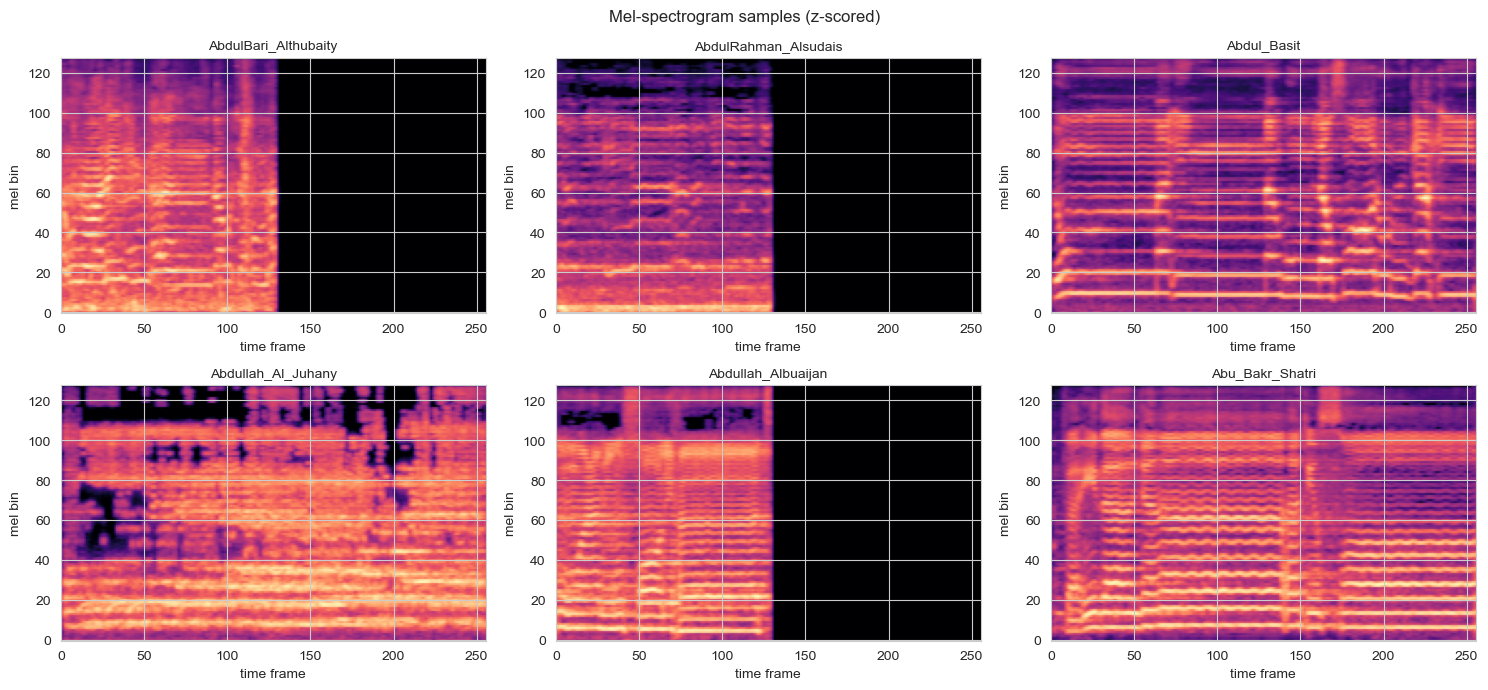

In [5]:
sample = train.groupby('reciter').first().reset_index().head(6)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    spec = wav_to_melspec(row['path'])
    im = ax.imshow(spec, origin='lower', aspect='auto', cmap='magma')
    ax.set_title(row['reciter'], fontsize=10)
    ax.set_xlabel('time frame')
    ax.set_ylabel('mel bin')
plt.suptitle('Mel-spectrogram samples (z-scored)')
plt.tight_layout()
plt.show()

## 6. CNN architecture

Compact CNN — three conv blocks (16→32→64 channels) + adaptive average pool + linear head. AdaptiveAvgPool2d makes the classifier size independent of input dimensions, so future spec-shape tweaks don't require rewiring.

In [6]:
class QariCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = QariCNN(num_classes).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {n_params:,}')
print(model)

Trainable params: 102,018
QariCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(128, eps=1e-05

## 7. Training loop with early stopping

In [7]:
BATCH_SIZE = 32
EPOCHS     = 25
LR         = 1e-3
PATIENCE   = 5

print('Building datasets (clean, cached spectrograms — fast retrain)…')
train_ds = MelSpecDataset(train, augment_prob=0.0)
val_ds   = MelSpecDataset(val,   augment_prob=0.0)
test_ds  = MelSpecDataset(test,  augment_prob=0.0)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val = 0.0
patience = PATIENCE
best_state = None

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    tr_loss = tr_correct = tr_n = 0
    for X, y in train_loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(X)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        tr_loss    += loss.item() * X.size(0)
        tr_correct += (out.argmax(1) == y).sum().item()
        tr_n       += X.size(0)

    model.eval()
    va_loss = va_correct = va_n = 0
    with torch.no_grad():
        for X, y in val_loader:
            X, y = X.to(device), y.to(device)
            out = model(X)
            loss = criterion(out, y)
            va_loss    += loss.item() * X.size(0)
            va_correct += (out.argmax(1) == y).sum().item()
            va_n       += X.size(0)

    tr_l = tr_loss / tr_n
    va_l = va_loss / va_n
    tr_a = tr_correct / tr_n
    va_a = va_correct / va_n
    history['train_loss'].append(tr_l)
    history['val_loss'].append(va_l)
    history['train_acc'].append(tr_a)
    history['val_acc'].append(va_a)

    dt = time.time() - t0
    print(f'ep {epoch:02d}  train loss={tr_l:.4f} acc={tr_a:.4f}  |  val loss={va_l:.4f} acc={va_a:.4f}  ({dt:.1f}s)')

    if va_a > best_val:
        best_val = va_a
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience = PATIENCE
    else:
        patience -= 1
        if patience == 0:
            print(f'Early stop at epoch {epoch}. Best val acc={best_val:.4f}')
            break

model.load_state_dict(best_state)
print(f'\nRestored best model — val acc {best_val:.4f}')

Building datasets (clean, cached spectrograms — fast retrain)…


ep 01  train loss=2.4119 acc=0.3125  |  val loss=1.8913 acc=0.4243  (107.7s)


ep 02  train loss=1.4661 acc=0.6044  |  val loss=1.1464 acc=0.7097  (23.8s)


ep 03  train loss=1.0428 acc=0.7174  |  val loss=0.8290 acc=0.7954  (23.5s)


ep 04  train loss=0.8081 acc=0.7840  |  val loss=0.7897 acc=0.7639  (23.3s)


...

ep 21  train loss=0.1450 acc=0.9582  |  val loss=0.0963 acc=0.9734  (23.6s)


ep 22  train loss=0.1259 acc=0.9637  |  val loss=0.1014 acc=0.9710  (22.3s)


ep 23  train loss=0.1234 acc=0.9657  |  val loss=0.0877 acc=0.9806  (23.6s)


ep 24  train loss=0.1220 acc=0.9631  |  val loss=0.1487 acc=0.9502  (24.8s)


ep 25  train loss=0.1108 acc=0.9670  |  val loss=0.1101 acc=0.9666  (24.7s)

Restored best model — val acc 0.9806


## 8. Loss & accuracy curves

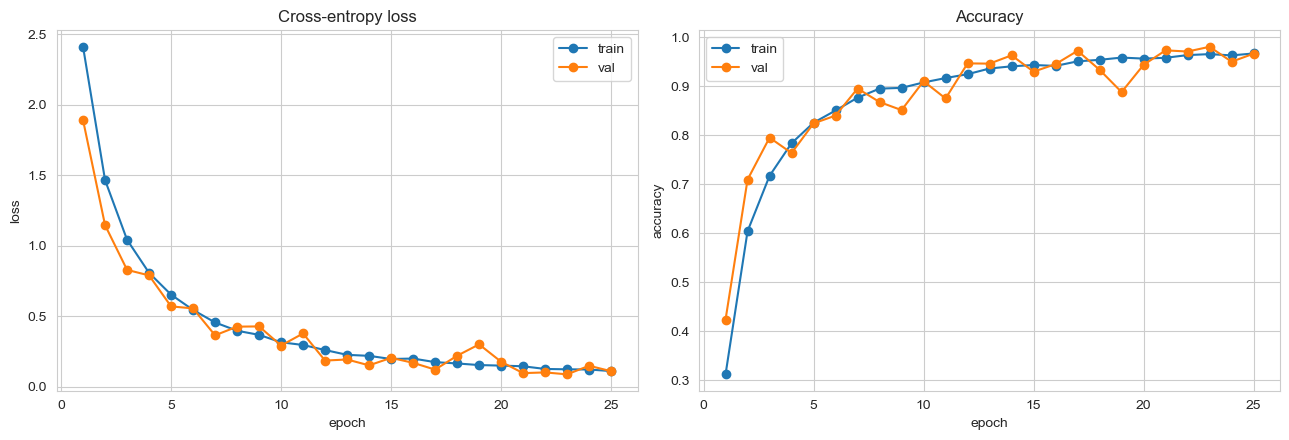

In [8]:
epochs_ran = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(epochs_ran, history['train_loss'], 'o-', label='train')
axes[0].plot(epochs_ran, history['val_loss'],   'o-', label='val')
axes[0].set(xlabel='epoch', ylabel='loss', title='Cross-entropy loss')
axes[0].legend()
axes[1].plot(epochs_ran, history['train_acc'], 'o-', label='train')
axes[1].plot(epochs_ran, history['val_acc'],   'o-', label='val')
axes[1].set(xlabel='epoch', ylabel='accuracy', title='Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

## 9. Test-set evaluation

In [9]:
model.eval()
all_pred, all_true, all_proba = [], [], []
with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        logits = model(X)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_proba.append(probs)
        all_pred.extend(logits.argmax(1).cpu().numpy())
        all_true.extend(y.numpy())

all_proba = np.concatenate(all_proba)
acc  = accuracy_score(all_true, all_pred)
top3 = top_k_accuracy_score(all_true, all_proba, k=3)
print(f'Test accuracy       : {acc:.4f}')
print(f'Test top-3 accuracy : {top3:.4f}')
print()
print(classification_report(all_true, all_pred, target_names=le.classes_))

Test accuracy       : 0.9840
Test top-3 accuracy : 0.9985

                               precision    recall  f1-score   support

         AbdulBari_Althubaity       1.00      0.98      0.99        60
         AbdulRahman_Alsudais       0.97      0.98      0.98        60
                  Abdul_Basit       0.98      1.00      0.99        60
           Abdullah_Al_Juhany       1.00      1.00      1.00        60
           Abdullah_Albuaijan       0.98      0.97      0.97        60
              Abu_Bakr_Shatri       1.00      1.00      1.00        60
               Ali_Alhothaify       1.00      0.90      0.95        60
                  Alijon_Qori       1.00      0.99      1.00       124
               Bander_Balilah       0.85      0.97      0.91        60
                  Fares_Abbad       1.00      1.00      1.00        60
                   Hani_Rifai       1.00      1.00      1.00        60
               Hasanxon_Yahyo       1.00      1.00      1.00        61
                 

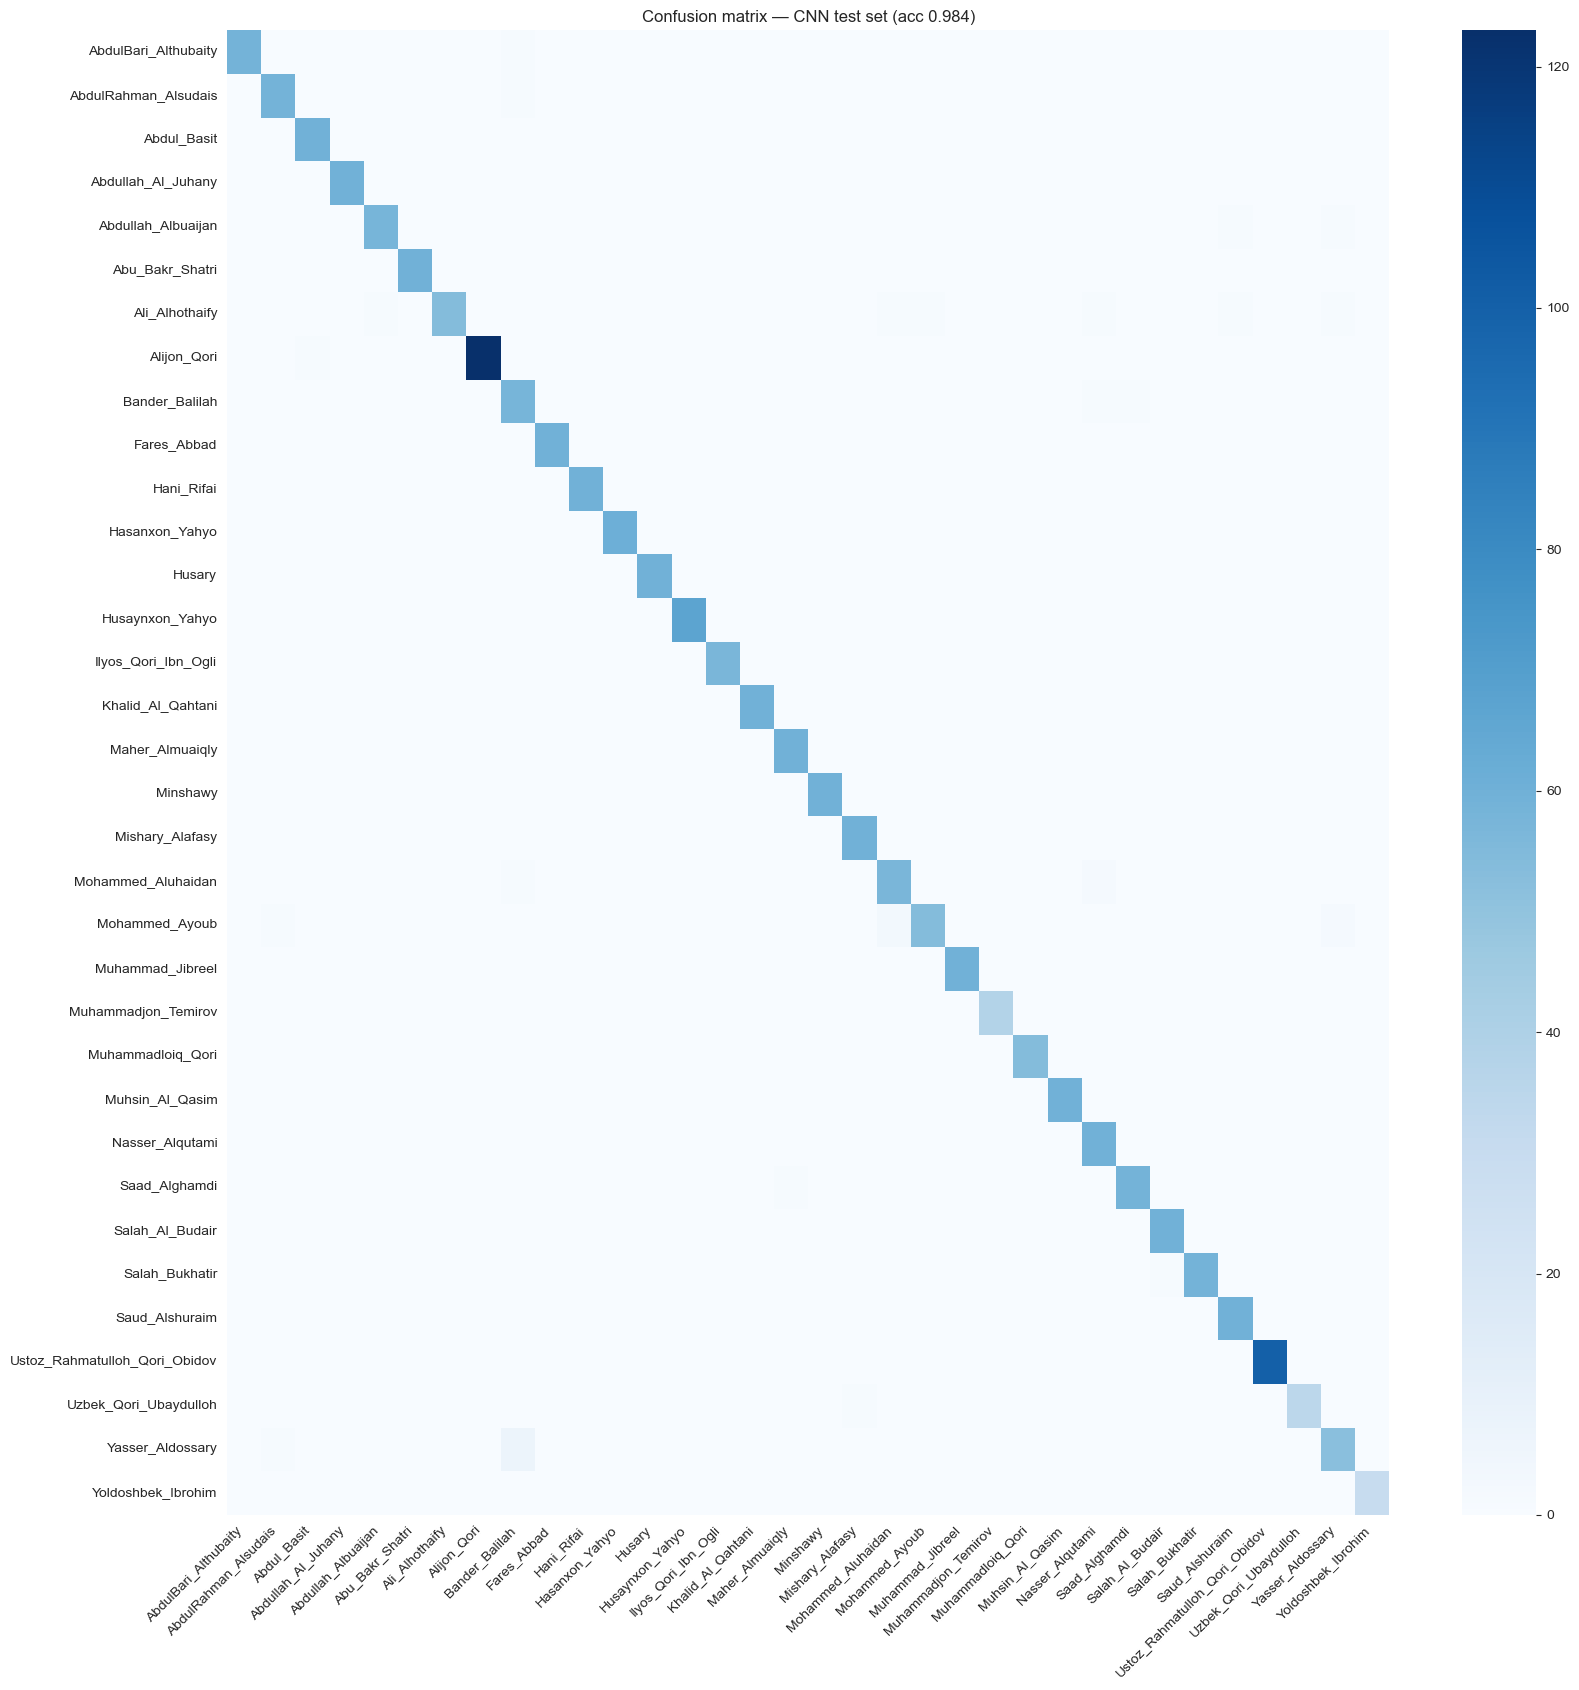

In [10]:
cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(max(8, num_classes * 0.5), max(6, num_classes * 0.5)))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title(f'Confusion matrix — CNN test set (acc {acc:.3f})')
plt.tight_layout()
plt.show()

## 10. Sample predictions with waveform + spectrogram

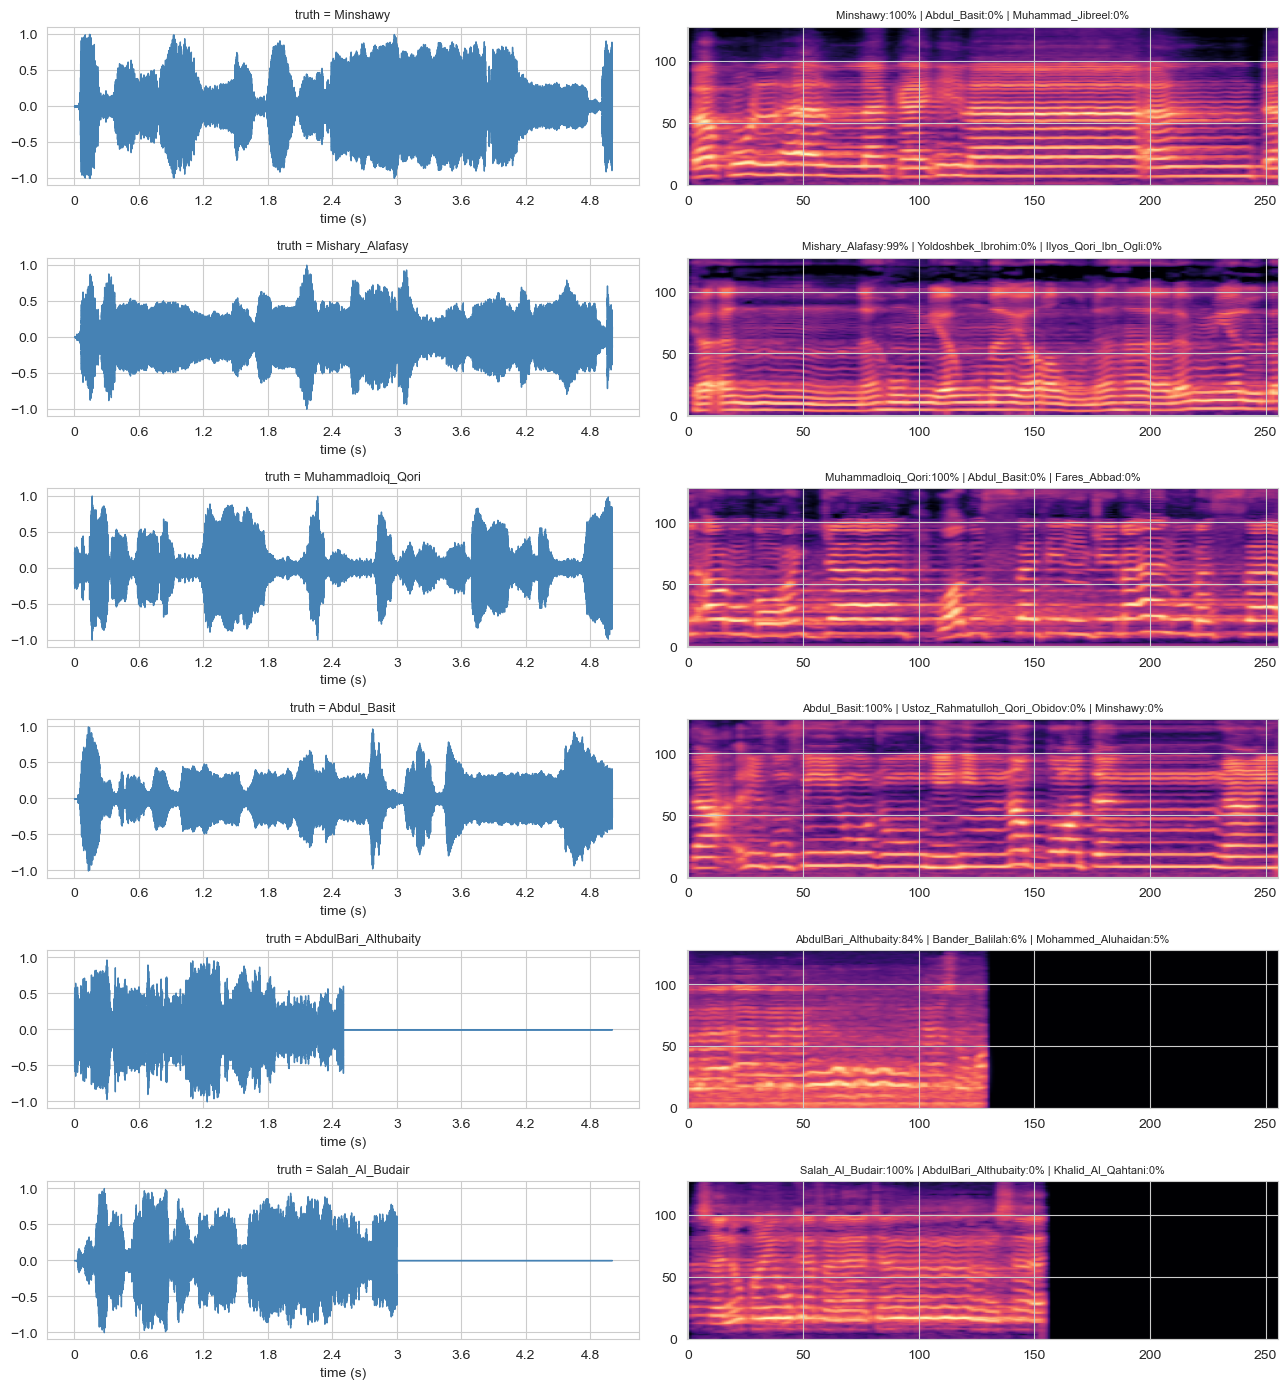

In [11]:
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(test), size=6, replace=False)

fig, axes = plt.subplots(6, 2, figsize=(13, 14))
for row, idx in enumerate(sample_idx):
    path  = test['path'].iloc[idx]
    true  = le.classes_[test['label'].iloc[idx]]
    y, _  = librosa.load(path, sr=SR, mono=True)
    spec  = wav_to_melspec(path)
    with torch.no_grad():
        img = torch.from_numpy(spec).unsqueeze(0).unsqueeze(0).to(device)
        prob = torch.softmax(model(img), dim=1).cpu().numpy().ravel()
    top3_i = prob.argsort()[-3:][::-1]
    guess_str = ' | '.join(f'{le.classes_[i]}:{prob[i]*100:.0f}%' for i in top3_i)

    librosa.display.waveshow(y, sr=SR, ax=axes[row, 0], color='steelblue')
    axes[row, 0].set_title(f'truth = {true}', fontsize=9)
    axes[row, 0].set_xlabel('time (s)')
    axes[row, 1].imshow(spec, origin='lower', aspect='auto', cmap='magma')
    axes[row, 1].set_title(guess_str, fontsize=8)
plt.tight_layout()
plt.show()

## 11. Save model artifacts

In [12]:
MODEL_PATH = Path('qari_cnn.pt')
META_PATH  = Path('qari_cnn_meta.joblib')

torch.save(model.state_dict(), MODEL_PATH)
meta = {
    'label_encoder': le,
    'classes':       list(le.classes_),
    'sr':            SR,
    'n_mels':        N_MELS,
    'img_h':         IMG_H,
    'img_w':         IMG_W,
    'best_val_acc':  best_val,
    'test_acc':      acc,
    'test_top3':     top3,
}
joblib.dump(meta, META_PATH)
print(f'Saved: {MODEL_PATH} ({MODEL_PATH.stat().st_size/1e6:.2f} MB)  &  {META_PATH}')

Saved: qari_cnn.pt (0.42 MB)  &  qari_cnn_meta.joblib


## 12. Classical vs CNN — comparison

In [13]:
sklearn_art = Path('qari_artifacts.joblib')
rows = [
    {'approach': 'CNN on mel-spec (PyTorch)', 'features': '128×256 image',
     'accuracy': acc, 'top3': top3, 'params': sum(p.numel() for p in model.parameters())},
]
if sklearn_art.exists():
    sk = joblib.load(sklearn_art)
    rows.append({
        'approach': f"Classical — {sk.get('model_name', 'sklearn')}",
        'features': '126 MFCC stats',
        'accuracy': float('nan'), 'top3': float('nan'), 'params': 'n/a',
    })
cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))
print('\n(sklearn numbers live in quran_qari_classifier_executed.ipynb — CNN accuracy above is what deploys.)')

                      approach       features  accuracy     top3 params
     CNN on mel-spec (PyTorch)  128×256 image  0.984035 0.998549 102018
Classical — LogisticRegression 126 MFCC stats       NaN      NaN    n/a

(sklearn numbers live in quran_qari_classifier_executed.ipynb — CNN accuracy above is what deploys.)
